# Notebook 6 — Evaluation and Model Comparison
This notebook compares Random Forest, XGBoost, and LSTM on the same test split. We focus on Precision, Recall, F1, and ROC-AUC because predictive maintenance requires both accurate ranking and strong failure detection.

## Imports and artifact loading
We load all saved models and prepared engineered test data.

The code below prepares both tabular and sequence test inputs.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
 )

cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.baseline import DROP_COLS
from src.models.lstm_model import SEQUENCE_LENGTH, create_sequences

sns.set_theme(style="whitegrid")
processed = project_root / "data" / "processed"
models_dir = project_root / "saved_models"

test_df = pd.read_csv(processed / "test_engineered.csv", parse_dates=["timestamp"])
drop_cols = [c for c in DROP_COLS if c in test_df.columns]
X_test_tab = test_df.drop(columns=drop_cols)
y_test = test_df["failure_within_48h"].values.astype(int)

rf = joblib.load(models_dir / "random_forest.pkl")
xgb = joblib.load(models_dir / "xgboost.pkl")
lstm = tf.keras.models.load_model(models_dir / "lstm_model.keras")

X_test_seq, y_test_seq = create_sequences(X_test_tab.values.astype(np.float32), y_test.astype(np.float32), SEQUENCE_LENGTH)
y_test_seq = y_test_seq.astype(int)

## Side-by-side metrics table
We compute Precision, Recall, F1, and ROC-AUC for all three models.

In [2]:
rf_prob = rf.predict_proba(X_test_tab)[:, 1]
xgb_prob = xgb.predict_proba(X_test_tab)[:, 1]
lstm_prob = lstm.predict(X_test_seq, verbose=0).ravel()

rf_pred = (rf_prob >= 0.5).astype(int)
xgb_pred = (xgb_prob >= 0.5).astype(int)
lstm_pred = (lstm_prob >= 0.5).astype(int)

metrics_df = pd.DataFrame([
    {"Model": "Random Forest", "Precision": precision_score(y_test, rf_pred), "Recall": recall_score(y_test, rf_pred), "F1": f1_score(y_test, rf_pred), "ROC-AUC": roc_auc_score(y_test, rf_prob)},
    {"Model": "XGBoost", "Precision": precision_score(y_test, xgb_pred), "Recall": recall_score(y_test, xgb_pred), "F1": f1_score(y_test, xgb_pred), "ROC-AUC": roc_auc_score(y_test, xgb_prob)},
    {"Model": "LSTM", "Precision": precision_score(y_test_seq, lstm_pred), "Recall": recall_score(y_test_seq, lstm_pred), "F1": f1_score(y_test_seq, lstm_pred), "ROC-AUC": roc_auc_score(y_test_seq, lstm_prob)},
]).set_index("Model")

display(metrics_df.style.format("{:.4f}"))

,Precision,Recall,F1,ROC-AUC
Model,,,,
Random Forest,0.9937,0.9718,0.9827,0.9977
XGBoost,0.9915,0.9776,0.9845,0.9971
LSTM,0.9623,0.9454,0.9538,0.9950


## Confusion matrices in one figure
All three confusion matrices are shown side by side for direct comparison.

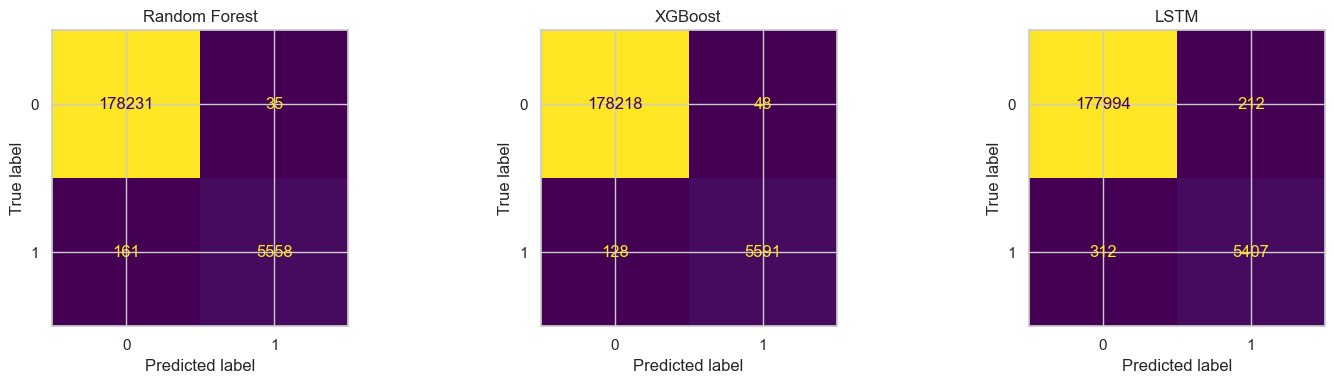

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cms = [
    (confusion_matrix(y_test, rf_pred), "Random Forest"),
    (confusion_matrix(y_test, xgb_pred), "XGBoost"),
    (confusion_matrix(y_test_seq, lstm_pred), "LSTM"),
]

for ax, (cm, title) in zip(axes, cms):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

## ROC curves in one figure
We overlay ROC curves with distinct colors and AUC labels.

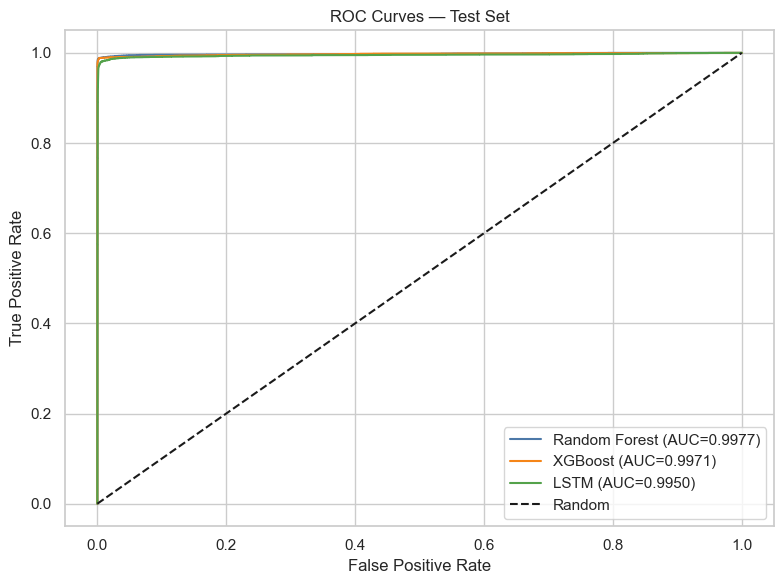

In [4]:
plt.figure(figsize=(8, 6))

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_seq, lstm_prob)

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, rf_prob):.4f})", color="#4C78A8")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_prob):.4f})", color="#F58518")
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={roc_auc_score(y_test_seq, lstm_prob):.4f})", color="#54A24B")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.title("ROC Curves — Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

### Recommendation
For production-oriented deployment in this project, **XGBoost** is recommended because it gives the strongest balance of recall, F1, and operational simplicity. **LSTM** remains valuable as a sequence model for temporal pattern learning, but it is heavier to train and did not outperform XGBoost on this test split.